In [1]:
import qiskit as qs
from qiskit_ibm_runtime import QiskitRuntimeService
from pathlib import Path
import numpy as np
from qiskit.visualization import array_to_latex as a2l
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit  

In [2]:
token_path = Path.cwd().parent / "secret" / "ibm_token.txt"
token = token_path.read_text().strip()

service = QiskitRuntimeService(channel='ibm_cloud', token=token)

QiskitRuntimeService.save_account(
    token=token,
    instance="open-instance",
    set_as_default=True,
    overwrite=True
)

qiskit_runtime_service._discover_account:WARNING:2026-07-13 04:12:42,304: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-07-13 04:12:48,415: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [3]:
# List available IBM backends
backends = service.backends()

for backend in backends:
    print(backend.name, backend.num_qubits)

qiskit_runtime_service.backends:WARNING:2026-07-03 16:55:30,044: Loading instance: open-instance, plan: open


ibm_fez 156
ibm_marrakesh 156
ibm_kingston 156


In [4]:
backend = service.least_busy(
    operational=True,
    simulator=False
)

print("Selected:", backend.name)

qiskit_runtime_service.backends:WARNING:2026-07-03 16:55:35,900: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-03 16:55:38,231: Using instance: open-instance, plan: open


Selected: ibm_marrakesh


In [5]:
for backend in service.backends():
    print("\nName:", backend.name)
    print("Qubits:", backend.num_qubits)
    print("Status:", backend.status())

qiskit_runtime_service.backends:WARNING:2026-07-03 16:55:38,942: Loading instance: open-instance, plan: open



Name: ibm_fez
Qubits: 156
Status: <qiskit_ibm_runtime.models.backend_status.BackendStatus object at 0x169e68b00>

Name: ibm_marrakesh
Qubits: 156
Status: <qiskit_ibm_runtime.models.backend_status.BackendStatus object at 0x169e68b00>

Name: ibm_kingston
Qubits: 156
Status: <qiskit_ibm_runtime.models.backend_status.BackendStatus object at 0x172c26b10>


In [6]:
ket1 = np.array([1,2,3]).reshape(-1,1)
ket2 = np.array([2,3,4]).reshape(-1,1)


In [7]:
ket1.T @ ket2

array([[20]])

In [8]:
ket1 @ ket2.T

array([[ 2,  3,  4],
       [ 4,  6,  8],
       [ 6,  9, 12]])

In [11]:
ket1 = np.random.rand(3,1)
ket2 = np.random.rand(3,1)

In [12]:
ket1.T @ ket2

array([[0.94624061]])

In [13]:
ket1 @ ket2.T

array([[0.04542443, 0.18176499, 0.08689611],
       [0.11878451, 0.47531394, 0.22723261],
       [0.2224288 , 0.89004457, 0.42550224]])

In [14]:
mat1 = np.random.rand(3,3)

In [15]:
ket1.T @ mat1 @ ket2

array([[1.67156015]])

In [16]:
print(ket1)

[[0.19961159]
 [0.52198265]
 [0.97743363]]


In [25]:
a2l(ket1.T @ ket2)

<IPython.core.display.Latex object>

In [50]:
psi1 = qs.quantum_info.Statevector([1/1/np.sqrt(2) ,1/1/np.sqrt(2) ])

In [51]:
psi1.draw('latex')

<IPython.core.display.Latex object>

In [101]:
psi1.is_valid()

True

In [71]:
outcome, psif = psi1.measure()

In [72]:
print(f"outcome:{outcome}\n post-measurement state:\n")
psif.draw('latex')

outcome:1
 post-measurement state:



<IPython.core.display.Latex object>

In [120]:
Nmeasurements = 10000
outcomeList = np.zeros(Nmeasurements)
for i in range(Nmeasurements):
    outcome, psif = psi1.measure()
    outcomeList[i]=outcome

In [154]:
outcomeList

array([0., 1., 1., ..., 0., 0., 1.], shape=(10000,))

In [155]:
outcomesDict = {"0": 0, "1": 0}
for value in outcomeList:
    if int(value)==0:
        outcomesDict["0"] += 1
    if int(value)==1:
        outcomesDict["1"] += 1

In [156]:
outcomesDict

{'0': 5011, '1': 4989}

In [ ]:
unique, counts = np.unique(outcomeList, return_counts=True)

In [169]:
unique

array([0., 1.])

In [172]:
outcomesDict = {str(int(i)): j for i,j in zip(unique,counts)}

Text(0, 0.5, 'Counts')

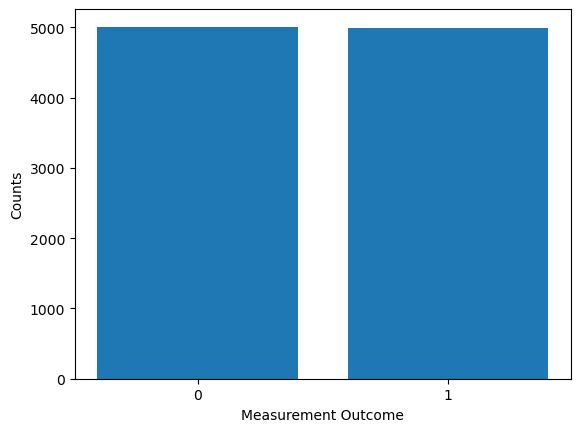

In [175]:
plt.bar(outcomesDict.keys(), outcomesDict.values())
plt.xlabel('Measurement Outcome')
plt.ylabel('Counts')

Text(0.5, 1.0, 'Histogram of Measurement Outcomes')

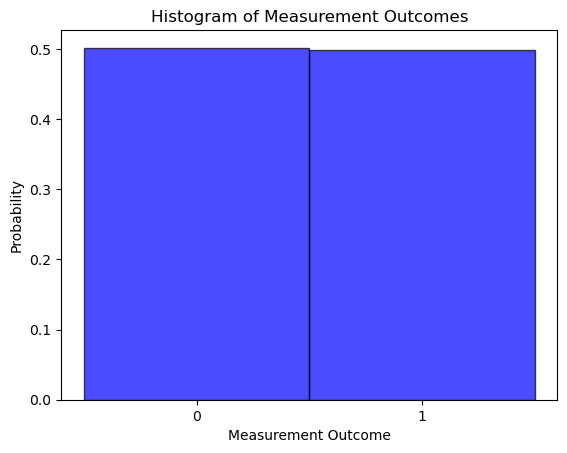

In [77]:
fig, ax = plt.subplots()
ax.hist(outcomeList, bins=np.arange(-0.5, 2, 1), density=True, alpha=0.7, color='blue', edgecolor='black')
ax.set_xticks([0, 1])
ax.set_xticklabels(['0', '1'])
ax.set_xlabel('Measurement Outcome')
ax.set_ylabel('Probability')
ax.set_title('Histogram of Measurement Outcomes')

In [203]:
circuit1 = QuantumCircuit(2)

In [204]:
circuit1.h(0)
circuit1.x(1)
circuit1.cx(1,0)

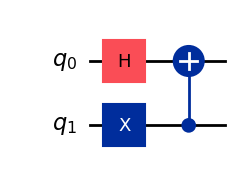

In [205]:
circuit1.draw("mpl")

In [11]:
QuantumCircuit.cx?

Signature:
QuantumCircuit.cx(
    self,
    control_qubit: 'QubitSpecifier',
    target_qubit: 'QubitSpecifier',
    label: 'str | None' = None,
    ctrl_state: 'str | int | None' = None,
) -> 'InstructionSet'
Docstring:
Apply :class:`~qiskit.circuit.library.CXGate`.

For the full matrix form of this gate, see the underlying gate documentation.

Args:
    control_qubit: The qubit(s) used as the control.
    target_qubit: The qubit(s) targeted by the gate.
    label: The string label of the gate in the circuit.
    ctrl_state:
        The control state in decimal, or as a bitstring (e.g. '1').  Defaults to controlling
        on the '1' state.

Returns:
    A handle to the instructions created.
File:      /opt/miniconda3/envs/cwq/lib/python3.14/site-packages/qiskit/circuit/quantumcircuit.py
Type:      function

In [214]:
qs.quantum_info.Operator(circuit1).draw("latex")

<IPython.core.display.Latex object>

In [217]:
psi1 = qs.quantum_info.Statevector([1,0])
psi2 = qs.quantum_info.Statevector([0,1])

In [219]:
psi3=psi1.tensor(psi2)

In [220]:
psi3.draw("latex")

<IPython.core.display.Latex object>

In [221]:
psi1.draw("latex")

<IPython.core.display.Latex object>

In [240]:
Id = qs.quantum_info.Operator.from_label('I')
H = qs.quantum_info.Operator.from_label('H')
X= qs.quantum_info.Operator.from_label('X')

In [243]:
HtenId = H.tensor(Id)

In [246]:
H.tensor(Id).draw("latex")

<IPython.core.display.Latex object>

In [242]:
H.tensor(Id).tensor(X).draw("latex")

<IPython.core.display.Latex object>

In [251]:
psi3.draw('latex')

<IPython.core.display.Latex object>

In [254]:
psi4=psi3.evolve(H.tensor(Id))

In [255]:
psi4.draw('latex')

<IPython.core.display.Latex object>

In [291]:
outcome, psi4f = psi4.measure([0,1])

In [292]:
outcome

np.str_('01')

In [293]:
psi4f.draw('latex')

<IPython.core.display.Latex object>

In [269]:
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_bloch_multivector

In [287]:
X,Y,Z,H,Id = Operator.from_label('X'), Operator.from_label('Y'), Operator.from_label('Z'), Operator.from_label('H'), Operator.from_label('I')

In [246]:
probAmp = np.random.rand(8)
probAmp /= np.linalg.norm(probAmp)
psi1 = Statevector(probAmp)
psi1.is_valid()
psi1.sample_counts(10)
#psi1.probabilities_dict()

{np.str_('001'): np.int64(1),
 np.str_('011'): np.int64(1),
 np.str_('100'): np.int64(1),
 np.str_('101'): np.int64(3),
 np.str_('110'): np.int64(2),
 np.str_('111'): np.int64(2)}

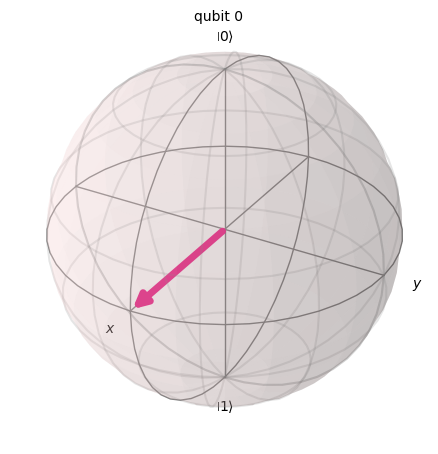

In [282]:
psi1 = Statevector.from_label('0')
psif = psi1.evolve(H)
plot_bloch_multivector(psif)

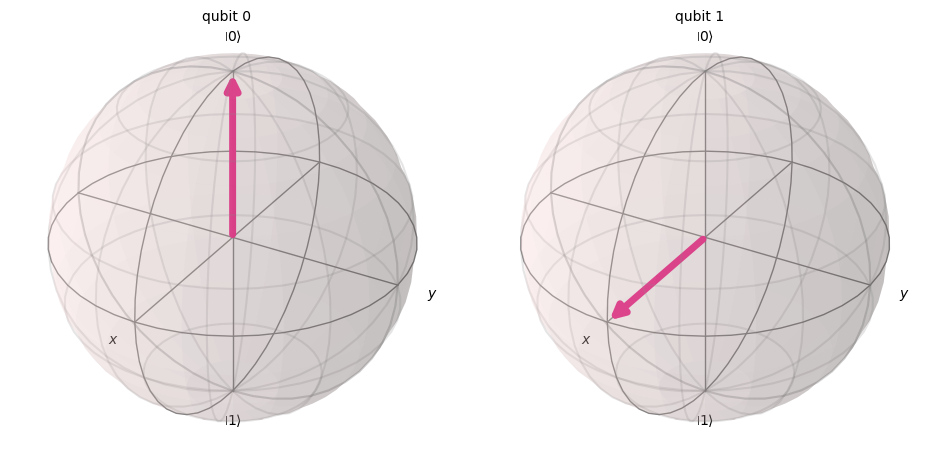

In [291]:
psi1 = Statevector.from_label('00')
plot_bloch_multivector(psi1)
U = H.tensor(Id)
psif = psi1.evolve(U)
plot_bloch_multivector(psif)

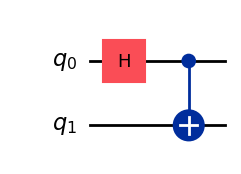

In [344]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.draw('mpl')

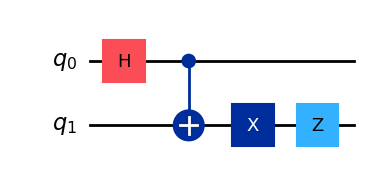

In [383]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.x(1)
qc.z(1)
qc.draw('mpl')

In [384]:
psi2=Statevector(qc).draw('latex')

In [385]:
psi2

<IPython.core.display.Latex object>

## Deutches Algorithm

In [ ]:
from dotenv import load_dotenv
import os
import qiskit as qs
from qiskit_ibm_runtime import QiskitRuntimeService
import numpy as np
from qiskit.visualization import array_to_latex as a2l
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit  

In [6]:
load_dotenv()
token = os.getenv("token")

service = QiskitRuntimeService(channel='ibm_cloud', token=token)

QiskitRuntimeService.save_account(
    token=token,
    instance="open-instance",
    set_as_default=True,
    overwrite=True
)

qiskit_runtime_service._discover_account:WARNING:2026-07-18 18:45:49,517: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-07-18 18:45:57,495: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [49]:
oracle_const0 = QuantumCircuit(2)
oracle_const1 = QuantumCircuit(2)
oracle_const1.x(1)
# f(x)=0, do nothing
# constant f(x)=1

In [ ]:
circuit1 = QuantumCircuit(2,1)
circuit1.x(1)
circuit1.h(0)
circuit1.h(1)
circuit1.append(oracle_const1.to_gate(label="Uf"), [0,1])
circuit1.h(0)
circuit1.measure(0,0)

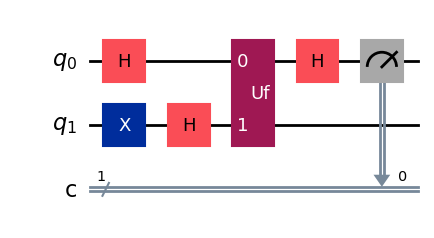

In [55]:
circuit1.draw("mpl")

In [ ]:
from qiskit import transpile

ModuleNotFoundError: No module named 'qiskit_aer'